In [25]:
import pandas as pd
import rpy2.ipython
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [26]:
%%R
library(tidyverse)
library(ggplot2)
#install.packages("remotes")
#remotes::install_github("hrbrmstr/waffle", force = TRUE)
#waffle::install_fa_fonts()
library(waffle)

In [27]:
df = pd.read_csv("oscars_cinematography.csv")
df

,Year,Film,Nominee,Winner,Gender
0,1927/28 (1st),The Devil Dancer;,George Barnes,False,Man
1,1927/28 (1st),Sunrise,Charles Rosher,True,Man
2,1927/28 (1st),Sunrise,Karl Struss,True,Man
3,1928/29 (2nd),Our Dancing Daughters,George Barnes,False,Man
4,1928/29 (2nd),White Shadows in the South Seas,Clyde De Vinna,True,Man
...,...,...,...,...,...
642,2025 (98th),Sinners,Autumn Durald Arkapaw,True,Woman
643,2025 (98th),Frankenstein,Dan Laustsen,False,Man
644,2025 (98th),Marty Supreme,Darius Khondji,False,Man
645,2025 (98th),One Battle After Another,Michael Bauman,False,Man


In [28]:
df["Gender"].value_counts()

Gender
Man      643
Woman      4
Name: count, dtype: int64

In [29]:
df_gender = pd.DataFrame({
    'group': ['Man', 'Woman'],
    'count': [481, 4]
})
df_gender

,group,count
0,Man,481
1,Woman,4


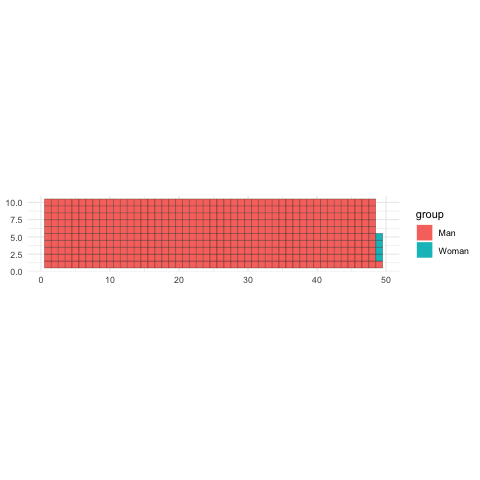

In [30]:
%%R -i df_gender

ggplot(df_gender, aes(fill = group, values = count)) +
  geom_waffle() +
  coord_equal() +
  theme_minimal()



In [ ]:
# I eventually decided to create a chart which outlines each nomination per year which means I needed to modify the dataframe. 

# This revealed an interesting observation about the dataset. The early editions include unofficial nominations, meaning movies that were considered
# in the category but were not officially announced as nominees. 
df["Year"].value_counts()


Year
1939 (12th)      17
1940 (13th)      16
1944 (17th)      16
1943 (16th)      16
1942 (15th)      16
                 ..
1937 (10th)       4
1934 (7th)        3
1932/33 (6th)     3
1931/32 (5th)     3
1927/28 (1st)     3
Name: count, Length: 98, dtype: int64

In [46]:
df.groupby('Year')['Nominee'].size()

Year
1927/28 (1st)    3
1928/29 (2nd)    5
1929/30 (3rd)    5
1930/31 (4th)    5
1931/32 (5th)    3
                ..
2021 (94th)      5
2022 (95th)      5
2023 (96th)      5
2024 (97th)      5
2025 (98th)      5
Name: Nominee, Length: 98, dtype: int64

In [65]:
df['Datapoint'] = df.groupby('Year').cumcount() + 1
df

,Year,Film,Nominee,Winner,Gender,Datapoint
0,1927/28 (1st),The Devil Dancer;,George Barnes,False,Man,1
1,1927/28 (1st),Sunrise,Charles Rosher,True,Man,2
2,1927/28 (1st),Sunrise,Karl Struss,True,Man,3
3,1928/29 (2nd),Our Dancing Daughters,George Barnes,False,Man,1
4,1928/29 (2nd),White Shadows in the South Seas,Clyde De Vinna,True,Man,2
...,...,...,...,...,...,...
642,2025 (98th),Sinners,Autumn Durald Arkapaw,True,Woman,1
643,2025 (98th),Frankenstein,Dan Laustsen,False,Man,2
644,2025 (98th),Marty Supreme,Darius Khondji,False,Man,3
645,2025 (98th),One Battle After Another,Michael Bauman,False,Man,4


In [70]:
# Winning film 
winners = df[df['Winner'] == True][['Year', 'Film']].rename(columns={'Film': 'Winner Title'}).drop_duplicates(subset="Year") 
df_plot = pd.merge(df, winners, how="inner", on="Year")
df_plot

,Year,Film,Nominee,Winner,Gender,Datapoint,Winner Title
0,1927/28 (1st),The Devil Dancer;,George Barnes,False,Man,1,Sunrise
1,1927/28 (1st),Sunrise,Charles Rosher,True,Man,2,Sunrise
2,1927/28 (1st),Sunrise,Karl Struss,True,Man,3,Sunrise
3,1928/29 (2nd),Our Dancing Daughters,George Barnes,False,Man,1,White Shadows in the South Seas
4,1928/29 (2nd),White Shadows in the South Seas,Clyde De Vinna,True,Man,2,White Shadows in the South Seas
...,...,...,...,...,...,...,...
642,2025 (98th),Sinners,Autumn Durald Arkapaw,True,Woman,1,Sinners
643,2025 (98th),Frankenstein,Dan Laustsen,False,Man,2,Sinners
644,2025 (98th),Marty Supreme,Darius Khondji,False,Man,3,Sinners
645,2025 (98th),One Battle After Another,Michael Bauman,False,Man,4,Sinners


In [48]:
counts = df.groupby('Year')['Nominee'].size().reset_index(name='Nominations')
counts

,Year,Nominations
0,1927/28 (1st),3
1,1928/29 (2nd),5
2,1929/30 (3rd),5
3,1930/31 (4th),5
4,1931/32 (5th),3
...,...,...
93,2021 (94th),5
94,2022 (95th),5
95,2023 (96th),5
96,2024 (97th),5


In [99]:
# Cleaning up the df so there is less information overload on the data viz

df_plot['Year'] = df_plot['Year'].str.extract(r'(\d{4}(?:/\d{2})?)')
df_plot

,Year,Film,Nominee,Winner,Gender,Datapoint,Winner Title
0,1927/28,The Devil Dancer;,George Barnes,False,Man,1,Sunrise
1,1927/28,Sunrise,Charles Rosher,True,Man,2,Sunrise
2,1927/28,Sunrise,Karl Struss,True,Man,3,Sunrise
3,1928/29,Our Dancing Daughters,George Barnes,False,Man,1,White Shadows in the South Seas
4,1928/29,White Shadows in the South Seas,Clyde De Vinna,True,Man,2,White Shadows in the South Seas
...,...,...,...,...,...,...,...
642,2025,Sinners,Autumn Durald Arkapaw,True,Woman,1,Sinners
643,2025,Frankenstein,Dan Laustsen,False,Man,2,Sinners
644,2025,Marty Supreme,Darius Khondji,False,Man,3,Sinners
645,2025,One Battle After Another,Michael Bauman,False,Man,4,Sinners


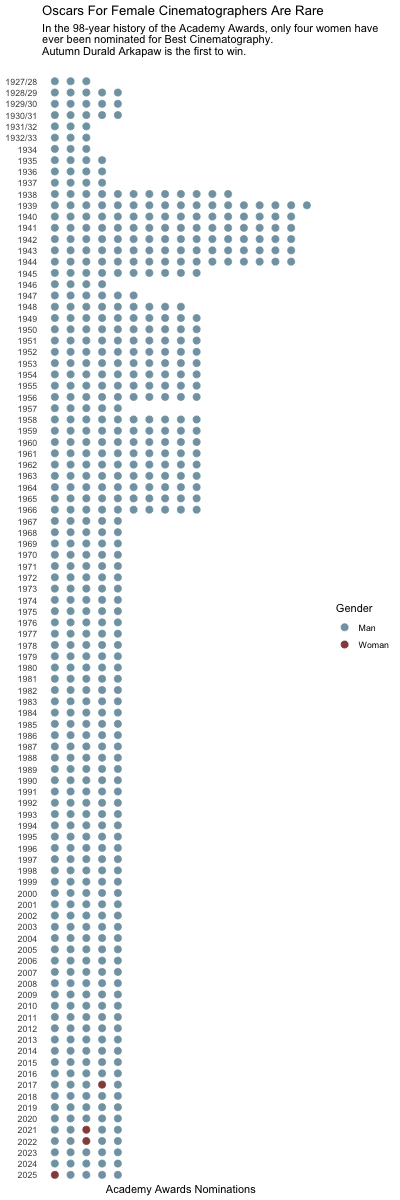

In [111]:
%%R -i df_plot -w 400 -h 1200

ggplot(df_plot, aes(x = Datapoint, y = Year, color = Gender)) +
  geom_point(size = 3) +
  scale_y_discrete(limits = rev(unique(df_plot$Year))) +
  labs(
    title = "Oscars For Female Cinematographers Are Rare", 
    subtitle = "In the 98-year history of the Academy Awards, only four women have \never been nominated for Best Cinematography. \nAutumn Durald Arkapaw is the first to win.\n",
    x = "Academy Awards Nominations", 
    y = NULL
  ) +
  scale_color_manual(
    values = c("Man" = "#82a2b1", "Woman" = "#954c4a")
  ) +
  theme_minimal() +
  theme(
    plot.background = element_blank(),
    panel.background = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
  )

In [112]:
%%R
ggsave("mobile_chart.svg", width = 4, height = 12, units = "in")

In [ ]:
df[df["Gender"] == "Woman"] # This is for explanatory purposes to later add annotations in Illustrator. 

,Year,Film,Nominee,Winner,Gender
605,2017 (90th),Mudbound,Rachel Morrison,False,Woman
624,2021 (94th),The Power of the Dog,Ari Wegner,False,Woman
629,2022 (95th),Elvis,Mandy Walker,False,Woman
642,2025 (98th),Sinners,Autumn Durald Arkapaw,True,Woman


In [113]:
# Celluloid Ceiling Report

data = {
    "Year": [2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "% Women Cinematographers": [5, 6, 6, 7, 7, 12, 7],  
    "% Women All Roles": [21, 23, 25, 24, 22, 23, 23],
}

df = pd.DataFrame(data)
df

,Year,% Women Cinematographers,% Women All Roles
0,2019,5,21
1,2020,6,23
2,2021,6,25
3,2022,7,24
4,2023,7,22
5,2024,12,23
6,2025,7,23


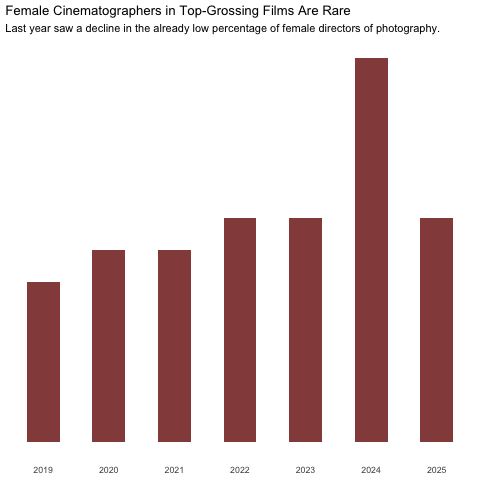

In [123]:
%%R -i df

ggplot(df, aes(x = Year, y = `% Women Cinematographers`)) +
  geom_bar(stat = "identity", width = 0.5, fill = "#954c4a") +
  scale_x_continuous(
    breaks = unique(df$Year)
   ) +
  labs(
    title = "Female Cinematographers in Top-Grossing Films Are Rare", 
    subtitle = "Last year saw a decline in the already low percentage of female directors of photography.",
    x = NULL, 
    y = NULL
  ) +
  theme_minimal() +
  theme(
    plot.background = element_blank(),
    panel.background = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank()
  )